<a href="https://colab.research.google.com/github/abheer2005/Machine-Learning-Projects/blob/main/LogisticRegressionBinaryClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Logistic Regression

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
df=pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


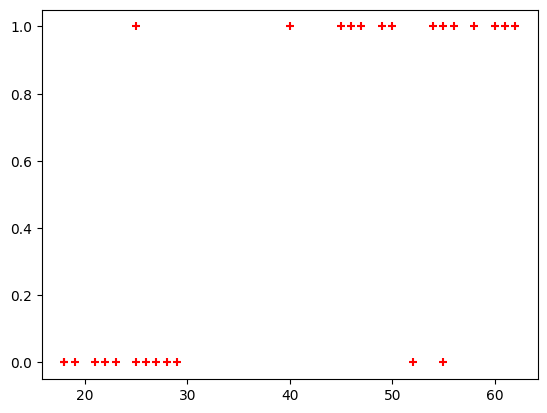

In [ ]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='red')

In [ ]:
df.shape     #27 rows , 2cols

(27, 2)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(df[['age']],df.bought_insurance,train_size=0.9)

In [ ]:
X_test

,age
16,25
0,22
3,52


In [ ]:
X_train

,age
21,26
4,46
25,54
19,18
5,56
18,19
20,21
15,55
7,60
11,28


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
model.predict(X_test)     #correct bcz see X_test ages are 47,49,54 and older people buy it so 1,1,1 so certaibly it is working fine

array([0, 0, 1])

In [ ]:
model.score(X_test,Y_test)

0.3333333333333333

In [ ]:
model.predict_proba(X_test)

array([[0.95126309, 0.04873691],
       [0.97331997, 0.02668003],
       [0.06551984, 0.93448016]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


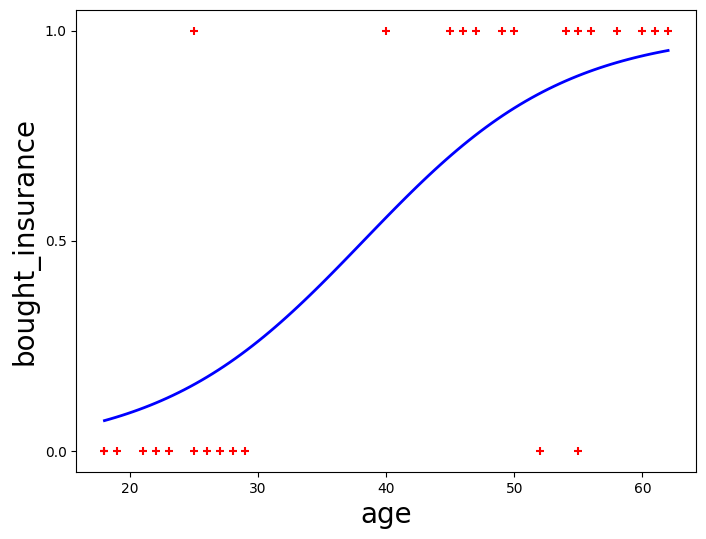

In [ ]:


# Step 1: Create a smooth range of ages
X_test = np.linspace(df.age.min(), df.age.max(), 100)

# Step 2: Predict probabilities for class 1 (bought insurance)
y_prob = model.predict_proba(X_test.reshape(-1,1))[:,1]

# Step 3: Plot sigmoid curve
plt.figure(figsize=(8,6))
plt.scatter(df.age, df.bought_insurance, color='red', marker='+')  # original points
plt.plot(X_test, y_prob, color='blue', linewidth=2)                # sigmoid curve
plt.xlabel('age', fontsize=20)
plt.ylabel('bought_insurance', fontsize=20)
plt.yticks([0, 0.5, 1])

plt.show()


**EXERCISE**

In [ ]:
 d=pd.read_csv("HR_comma_sep.csv")
 d.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**Satisfaction Level vs Retention Impact of satisfaction level on retention**

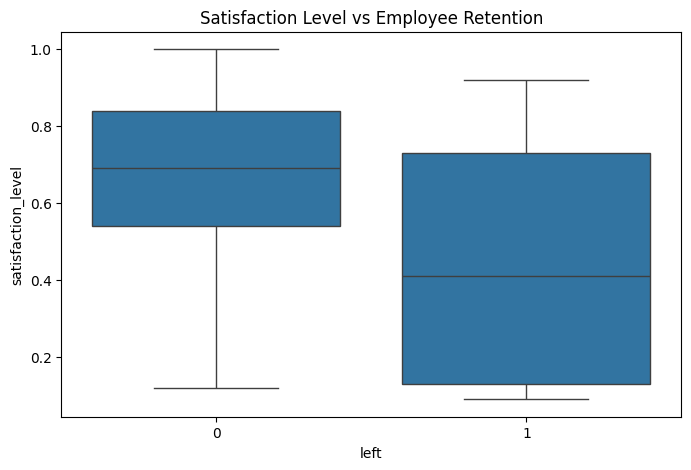

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(x="left", y="satisfaction_level", data=d)
plt.title("Satisfaction Level vs Employee Retention")
plt.show()


**Average Monthly Hours vs Retention Impact of average monthly hours on retention**


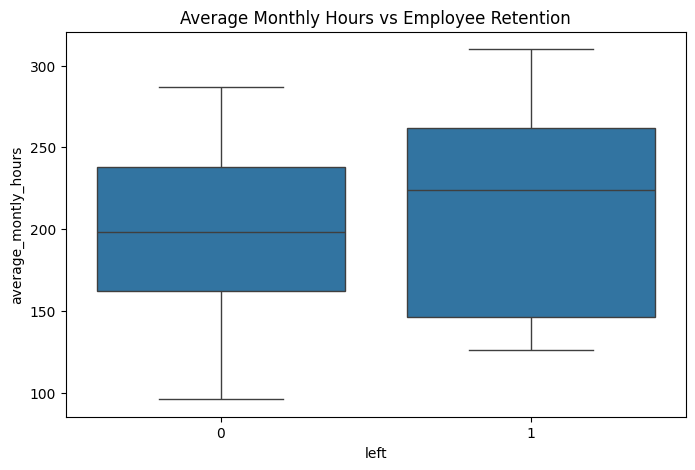

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="left", y="average_montly_hours", data=d)
plt.title("Average Monthly Hours vs Employee Retention")
plt.show()

**Tenure (Time Spent in Company) vs Retention Impact of tenure on Retention**

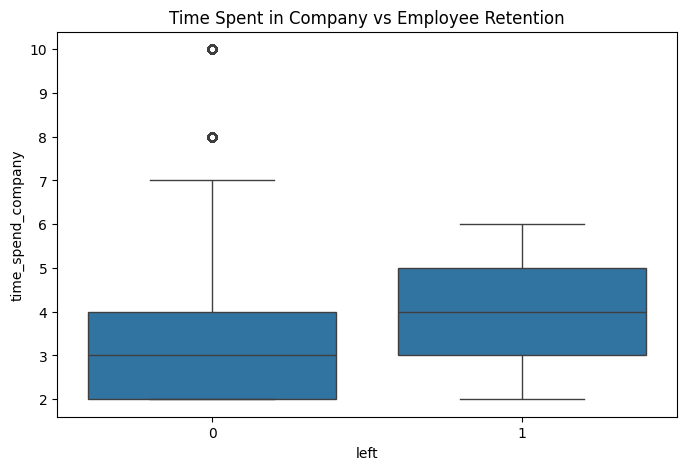

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="left", y="time_spend_company", data=d)
plt.title("Time Spent in Company vs Employee Retention")
plt.show()


**Plot Bar Chart Showing Impact of Salaries on Retention**

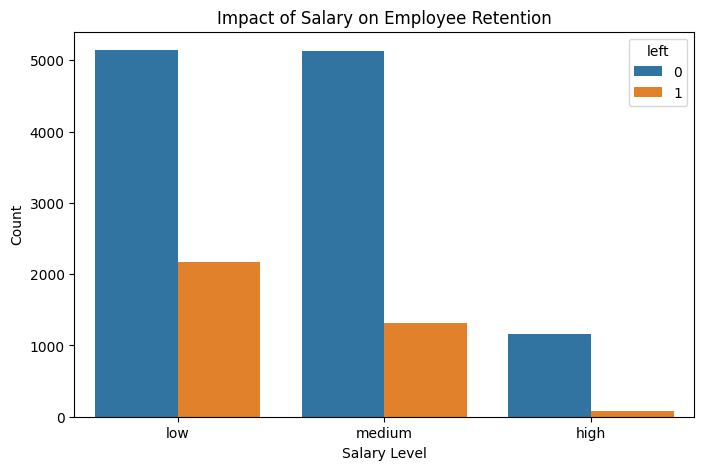

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="salary", hue="left", data=d)
plt.title("Impact of Salary on Employee Retention")
plt.xlabel("Salary Level")
plt.ylabel("Count")
plt.show()


**Plot Bar Chart Showing Correlation Between Department and Employee Retention**

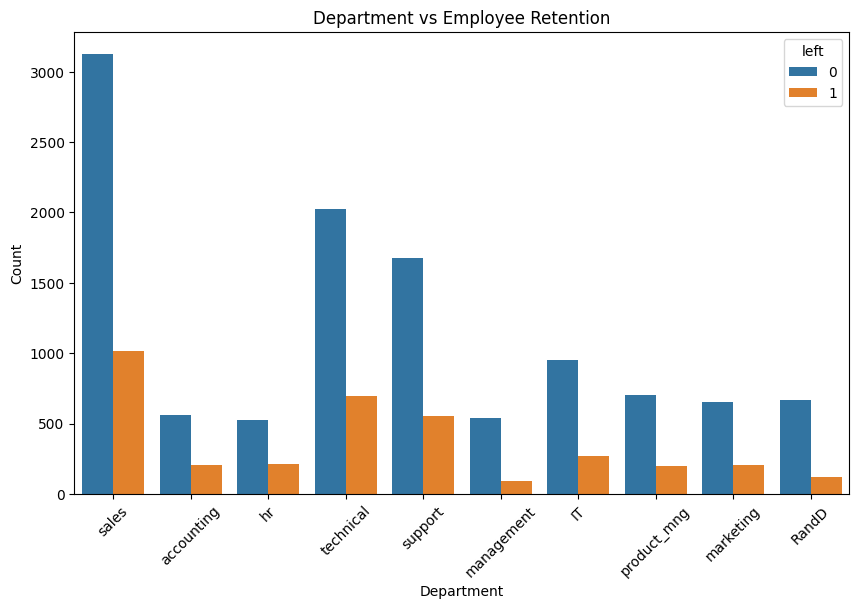

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x="Department", hue="left", data=d)
plt.xticks(rotation=45)
plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()


**Build a Logistic Regression Model**

In [ ]:
# One-hot encode categorical variables if they haven't been encoded yet
if 'Department' in d.columns and 'salary' in d.columns:
    d = pd.get_dummies(d, columns=["Department", "salary"], drop_first=True)

# Select features based on Step 1 EDA
features = ["satisfaction_level", "average_montly_hours", "time_spend_company", "promotion_last_5years",
            "salary_low", "salary_medium"]
X = d[features]
y = d["left"]      #X is independent (based on step 1) factors while y is dependent retention whether employee will be retained by company or not

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_test

,left
5996,0
8546,0
7985,0
12555,1
14020,0
...,...
12845,0
3495,0
8002,0
7009,0


In [ ]:
model.score(X_test,y_test)

0.775